<h1 style="color: #0D47A1; font-weight: bold">
    Entrega TP3
</h1>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch import nn
from tqdm import tqdm

from copy import deepcopy

In [3]:
sys.path.append("..")

from src.utils.plotting import (plot_random_images, plot_training_history,
    evaluate_model, compare_models)
from src.utils.preprocessing import (data_split, scaler)
from src.evaluation.grid_search import random_grid_search_custom, random_grid_search_torch
from src.training.train import train_and_eval, train_loop
from src.utils.utils import get_best_config

from src.models.custom.layers import DenseLayer
from src.models.custom.neural_network import SecuentialNeuralNetwork
from src.models.custom.activations import ReLU, SoftMax
from src.models.custom.optimizers import GradientDescent, ADAM
from src.models.custom.loss import CrossEntropy
from src.models.torch.mlp import MLP

<h2 style="color: #1976D2; font-weight: 500">
    1. Análisis exploratorio y preprocesamiento
</h2>

In [4]:
X_images = np.load("../data/X_images.npy")
y_images = np.load("../data/y_images.npy")

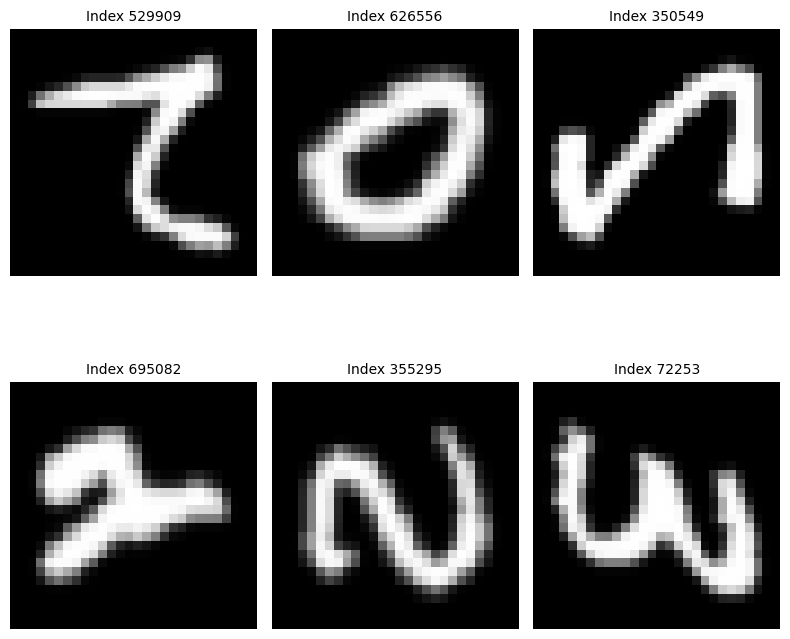

In [5]:
plot_random_images(X_images, image_shape=(28, 28), n=6)

In [6]:
X_images = X_images.reshape(X_images.shape[0], -1)

Cantidad de clases

In [7]:
output_dim = len(set(y_images.tolist()))
print("Cantidad de clases:", output_dim)

Cantidad de clases: 47


In [8]:
input_dim = X_images.shape[1]
print("Cantidad de 'features':", input_dim)

Cantidad de 'features': 784


In [9]:
rows = X_images.shape[0]
print(rows)

809555


Normalizo el dataset dividiendo por 255 así el máximo es 1.

Luego:

Dividir en Train, Validation y Test
- Dev 0.9, Test 0.1
- Train 7/9 de Dev, Val 2/9 de Dev

Sobre el dataset total:
- Train 0.7, Val 0.2, Test 0.1

In [10]:
X_images = scaler(X_images)

# Shuffle and split
X_dev, y_dev, X_test, y_test = data_split(X_images, y_images, frac=0.8)
X_train, y_train, X_val, y_val = data_split(X_dev, y_dev, frac=7/9)

del X_images
del y_images

In [11]:
total_epochs = 150

<h2 style="color: #1976D2; font-weight: 500">
    2. Implementación y Entrenamiento de una Red Neuronal Básica
</h2>

Incisos **a** y **b** en `src/models/`

<h3 style="color: #00B0FF; font-weight: 400">
    Modelo M0
</h3>

- 1ra capa oculta:
    - 128 nodos con activación ReLU
- 2da capa oculta:
    - 64 nodos con activación ReLU
- Capa de salida:
    - 1 nodo con activación SoftMax

In [12]:
layers_m0 = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m0 = SecuentialNeuralNetwork(
    layers_m0, 
    GradientDescent(learning_rate=0.05), 
    CrossEntropy()
)

m0_test = deepcopy(m0)

Entrenamiento del modelo

In [13]:
last_epoch_m0 = m0.fit(X=X_train, y=y_train, epochs=total_epochs, batch_size=None, X_val=X_val, y_val=y_val, early_stopping=None)

Training: 100%|██████████| 150/150 [13:00<00:00,  5.20s/ep]


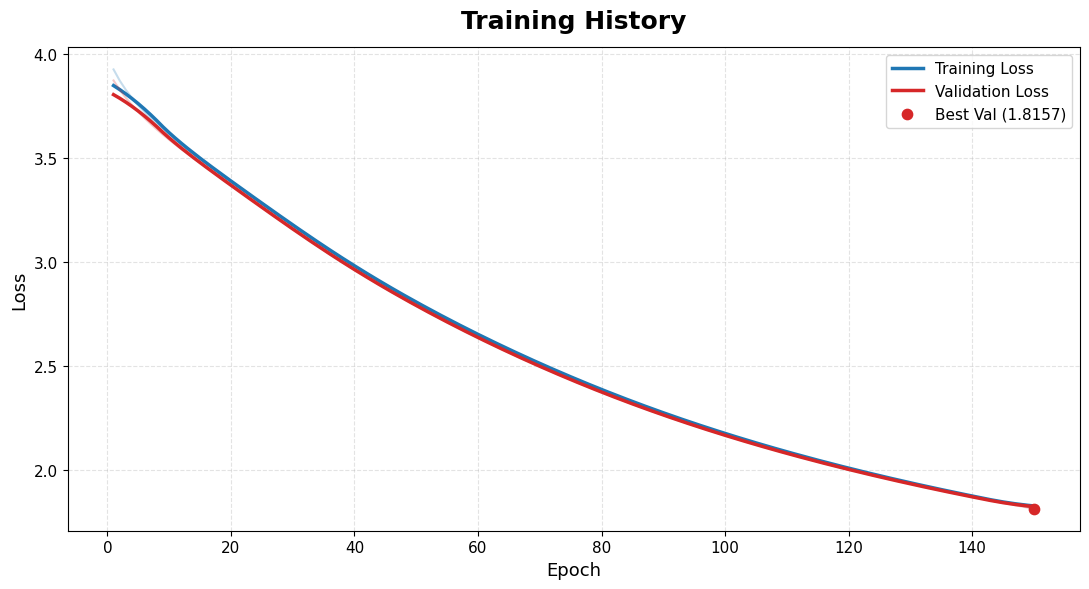

In [14]:
plot_training_history(m0.train_loss, m0.val_loss)

Métricas

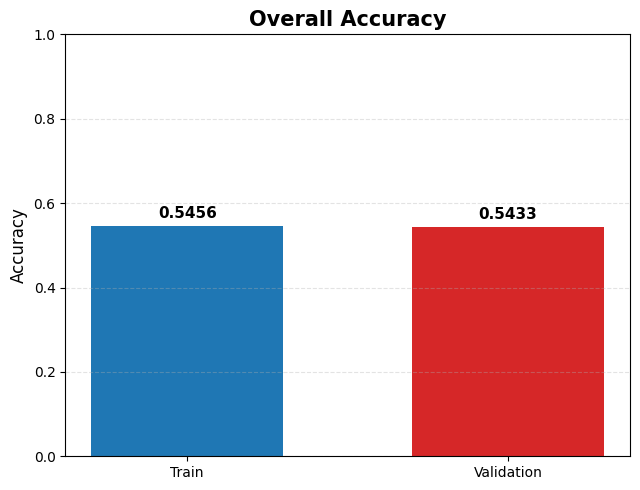

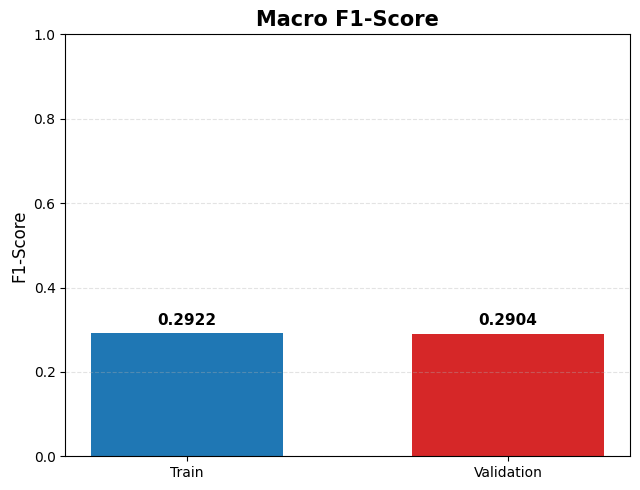

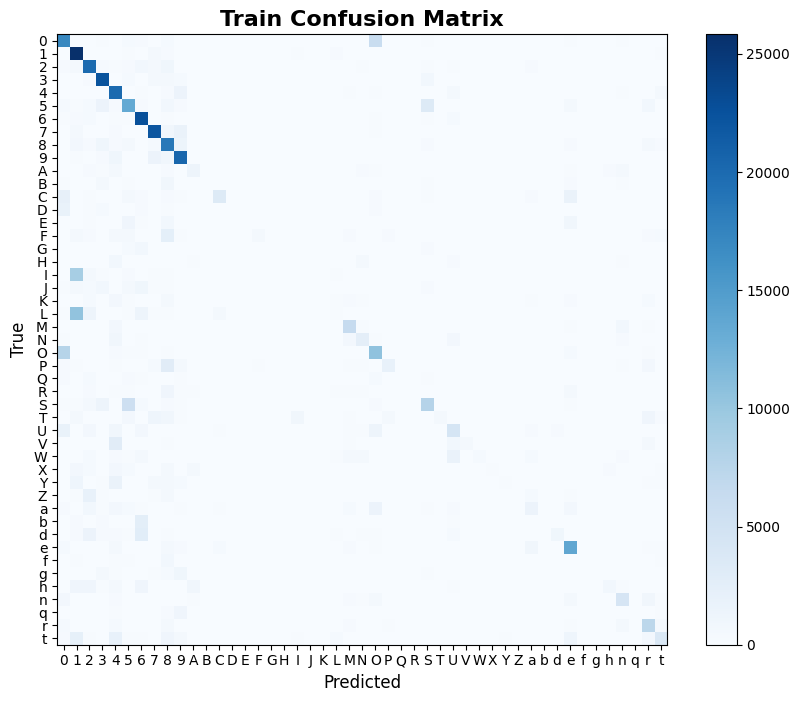

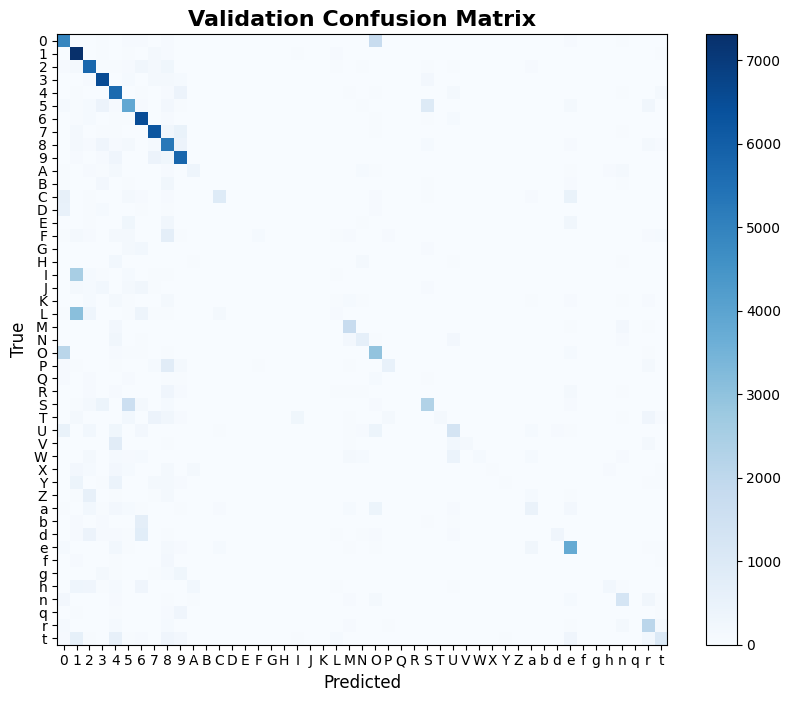

In [15]:
evaluate_model(m0, X_train, y_train, X_val, y_val)

<h2 style="color: #1976D2; font-weight: 500">
    3. Implementación y Entrenamiento de una Red Neuronal Avanzada
</h2>

**Mejoras al algoritmo de entrenamiento y reportar el efecto observado sobre el tiempo de entrenamiento y la performance del modelo resultante**

In [16]:
epochs_test = 50

search_train_size = int(min(X_train.shape[0]*0.2, X_train.shape[0]))
search_val_size = int(min(X_val.shape[0]*0.2, X_val.shape[0]))

search_train_idx = np.random.choice(X_train.shape[0], size=search_train_size, replace=False)
search_val_idx = np.random.choice(X_val.shape[0], size=search_val_size, replace=False)

X_train_search = X_train[search_train_idx]
y_train_search = y_train[search_train_idx]
X_val_search = X_val[search_val_idx]
y_val_search = y_val[search_val_idx]

- **Rate scheduling lineal (con saturación)**

In [17]:
linear_scheduling = {"type": "linear", "lr_min": 0.001, "k": 0.01}

layers_m_test = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_test = SecuentialNeuralNetwork(
    layers_m_test, 
    GradientDescent(learning_rate=0.01, scheduling=linear_scheduling), 
    CrossEntropy()
)

In [18]:
m_test.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 50/50 [00:14<00:00,  3.40ep/s]


50

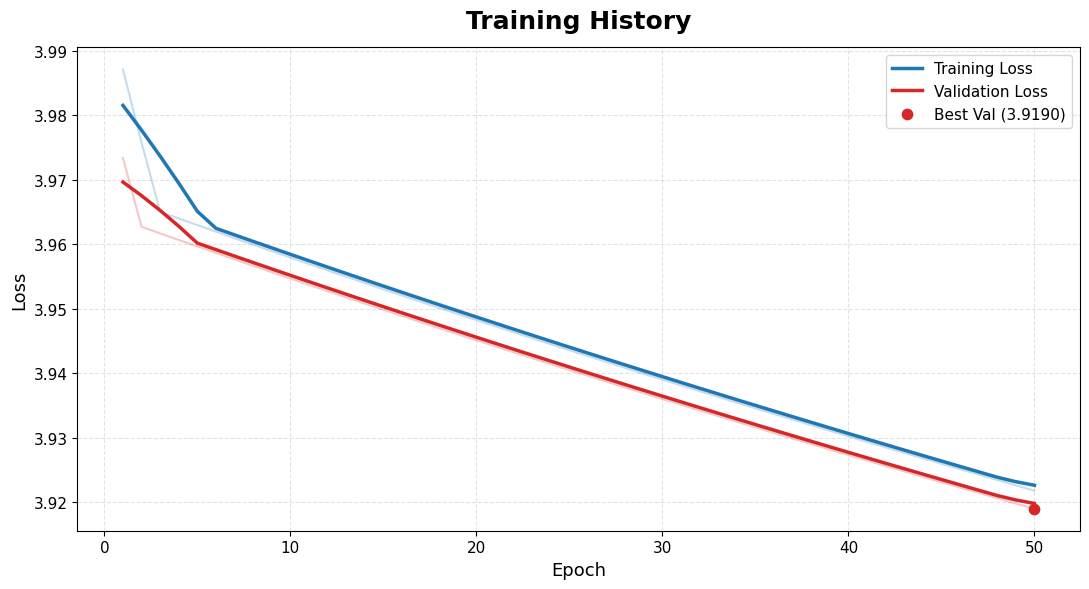

In [19]:
plot_training_history(m_test.train_loss, m_test.val_loss)

- **Rate scheduling exponencial**

In [20]:
exponential_scheduling = {"type": "exponential", "gamma": 0.9}

layers_m_test = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_test = SecuentialNeuralNetwork(
    layers_m_test, 
    GradientDescent(learning_rate=0.01, scheduling=exponential_scheduling), 
    CrossEntropy()
)

In [21]:
m_test.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 50/50 [00:13<00:00,  3.66ep/s]


50

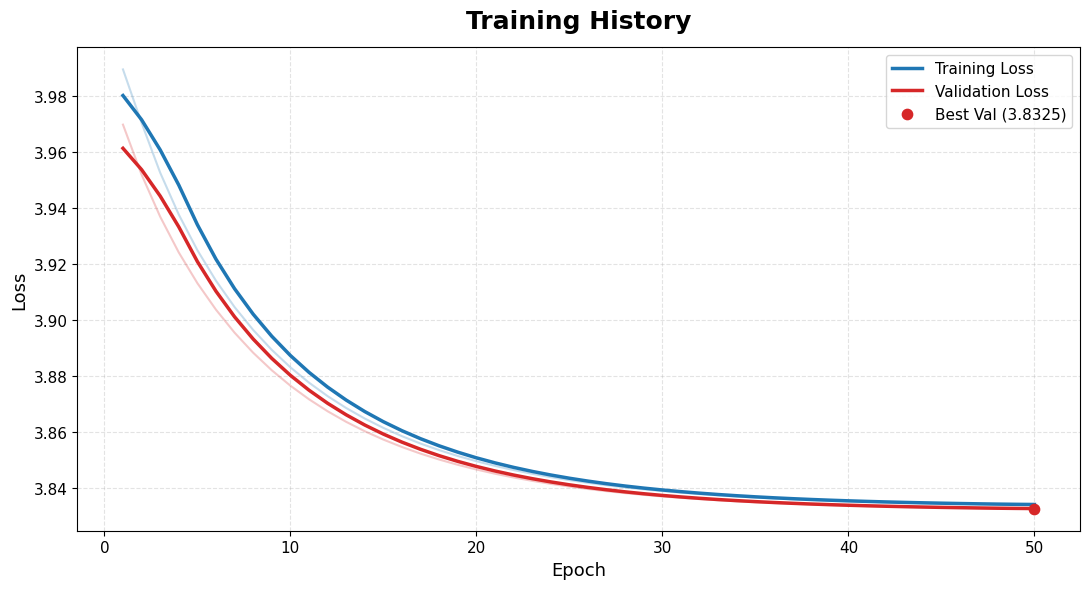

In [22]:
plot_training_history(m_test.train_loss, m_test.val_loss)

- **Mini-batch stochastic gradient descent**

In [23]:
layers_m_test = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_test = SecuentialNeuralNetwork(
    layers_m_test, 
    GradientDescent(learning_rate=0.01), 
    CrossEntropy()
)

In [24]:
m_test.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=128, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 50/50 [01:09<00:00,  1.40s/ep]


50

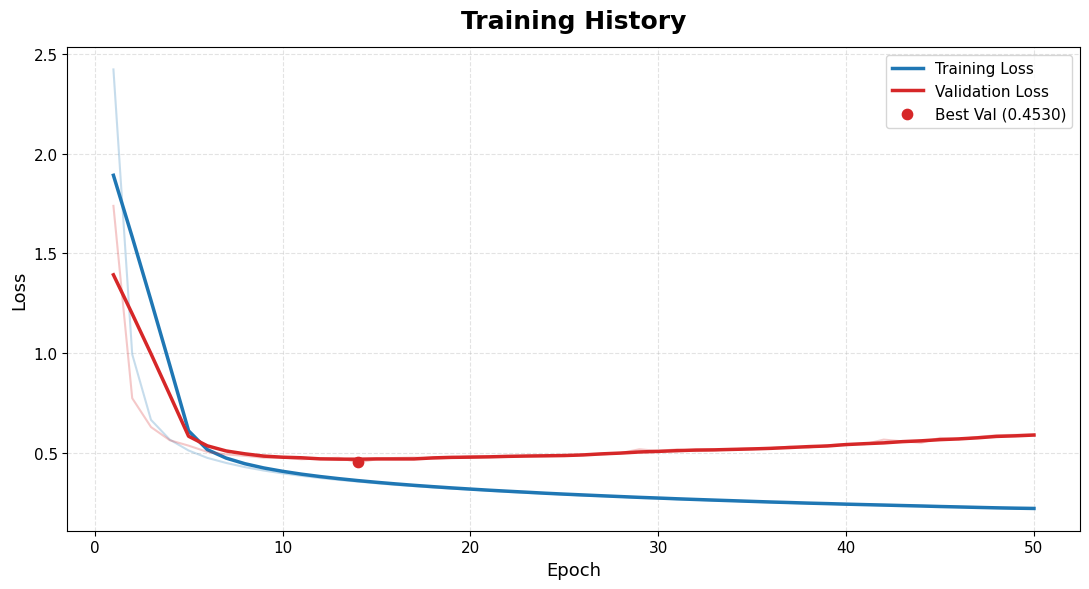

In [25]:
plot_training_history(m_test.train_loss, m_test.val_loss)

- **Optimizador Adam**

In [26]:
layers_m_test = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_test = SecuentialNeuralNetwork(
    layers_m_test, 
    ADAM(), 
    CrossEntropy()
)

In [27]:
m_test.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 50/50 [00:13<00:00,  3.65ep/s]


50

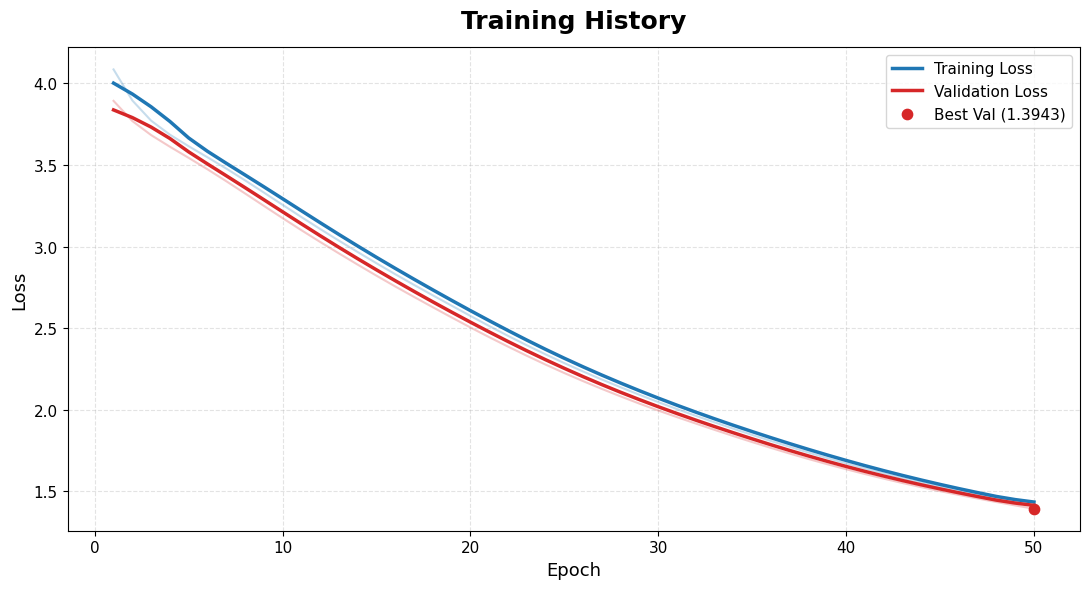

In [28]:
plot_training_history(m_test.train_loss, m_test.val_loss)

- **Regularización (L2, Early Stopping)**

In [29]:
l2_test = 0.01

layers_m_test = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=l2_test),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=l2_test),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=l2_test)
]

m_test = SecuentialNeuralNetwork(
    layers_m_test, 
    GradientDescent(learning_rate=0.01), 
    CrossEntropy()
)

In [30]:
m_test.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=10)

Training: 100%|██████████| 50/50 [00:14<00:00,  3.56ep/s]


50

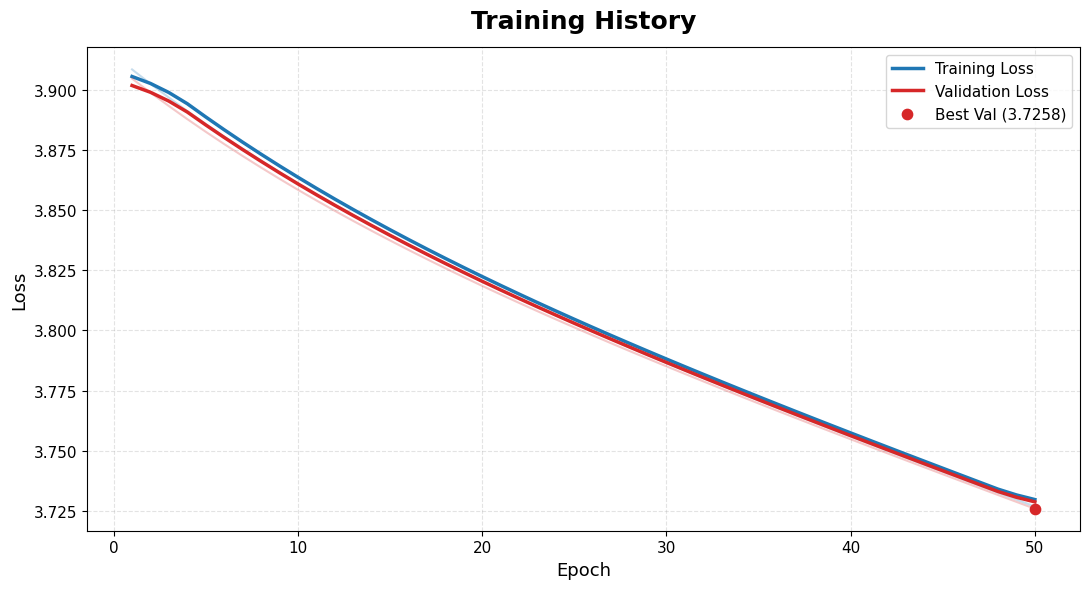

In [31]:
plot_training_history(m_test.train_loss, m_test.val_loss)

---

**Random Grid Search para M1**

In [32]:
possible_configs = {
    "layers": [
        (128, 64), 
        (256, 128, 64), 
        (256, 128)],
    "l2": [0., 1e-5, 1e-3],
    "batch_size": [128, 256],
    "scheduling": [
        None, 
        {"type": "linear", "lr_min": 1e-5, "k": 1e-5}, 
        {"type": "exponential", "gamma": 0.99}]
}

epochs_search = 50
early_stopping = 5
K_models = 5

models, model_configs = random_grid_search_custom(input_dim, output_dim, X_train_search, 
    y_train_search, X_val_search, y_val_search, epochs_search, K_models, 
    possible_configs, early_stopping=early_stopping)

  0%|          | 0/5 [00:00<?, ?it/s]


Model: 0
Config: {'layers': (256, 128), 'l2': 0.0, 'batch_size': 128, 'scheduling': {'type': 'exponential', 'gamma': 0.99}}



 20%|██        | 1/5 [01:07<04:28, 67.17s/it]

Early stopping after epoch: 8


Model: 1
Config: {'layers': (256, 128, 64), 'l2': 0.0, 'batch_size': 128, 'scheduling': None}



 40%|████      | 2/5 [02:26<03:42, 74.32s/it]

...

Early stopping after epoch: 9


Model: 3
Config: {'layers': (256, 128, 64), 'l2': 0.0, 'batch_size': 128, 'scheduling': None}



 80%|████████  | 4/5 [05:20<01:24, 84.26s/it]

Early stopping after epoch: 11


Model: 4
Config: {'layers': (128, 64), 'l2': 0.0, 'batch_size': 128, 'scheduling': {'type': 'exponential', 'gamma': 0.99}}



100%|██████████| 5/5 [06:02<00:00, 72.45s/it]

Early stopping after epoch: 9



In [33]:
compare_models(models, list(model_configs.keys()))

 Model  Best Val Loss  Best Train Loss  Best Epoch  Final Train Loss  Final Val Loss  Epochs Trained
     4       0.506125         0.457846           5          0.384324        0.546213              10
     2       0.507892         0.419337           5          0.352566        0.583268              10
     3       0.510603         0.413732           7          0.381252        0.592503              12
     1       0.512244         0.445301           5          0.389056        0.542387              10
     0       0.513069         0.452824           4          0.357358        0.586614               9


<h3 style="color: #00B0FF; font-weight: 400">
    Modelo M1
</h3>

In [34]:
config_m1 = get_best_config(models, model_configs)

m1 = SecuentialNeuralNetwork.build_from_config(input_dim, output_dim, ReLU, 
    SoftMax, config_m1, ADAM, CrossEntropy)

m1_test = deepcopy(m1)

In [35]:
last_epoch_m1 = m1.fit(X_train, y_train, epochs=total_epochs, batch_size=config_m1["batch_size"], 
    X_val=X_val, y_val=y_val, early_stopping=early_stopping)

Training:   7%|▋         | 10/150 [02:54<40:47, 17.48s/ep]

Early stopping after epoch: 10


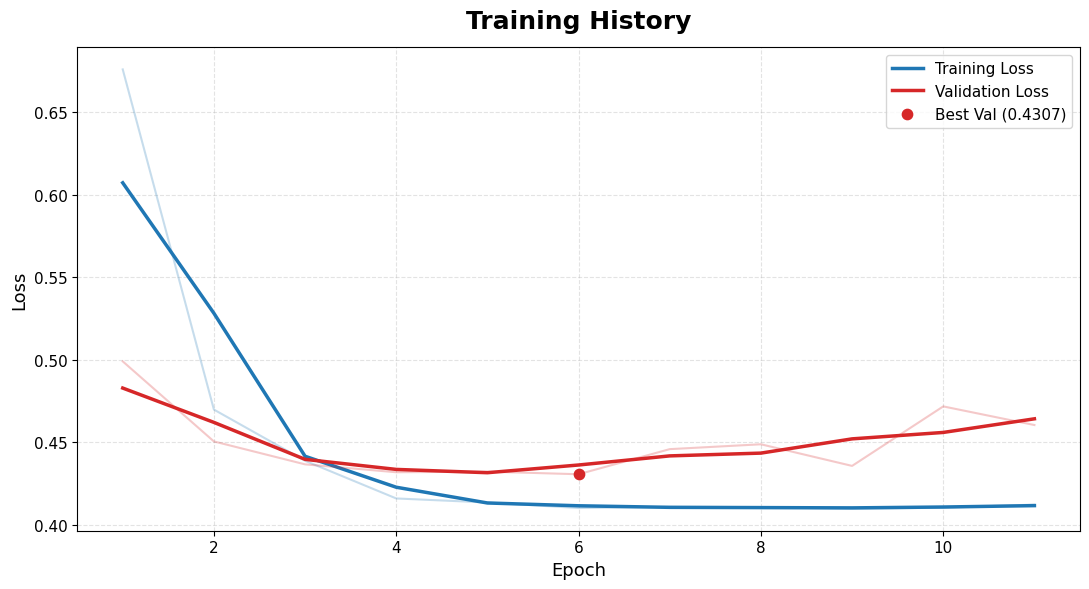

In [36]:
plot_training_history(m1.train_loss, m1.val_loss)

Métricas

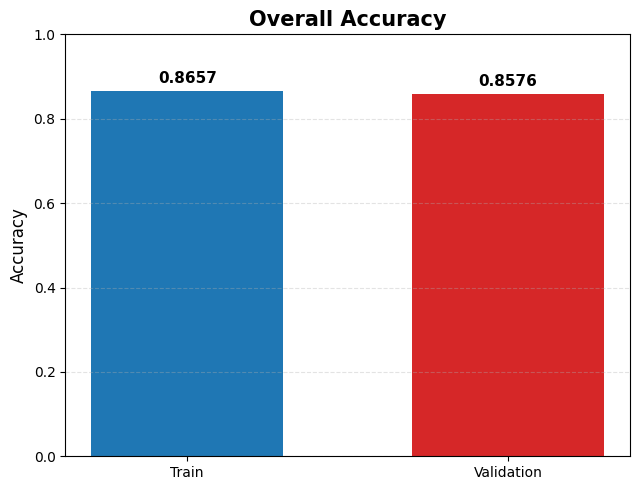

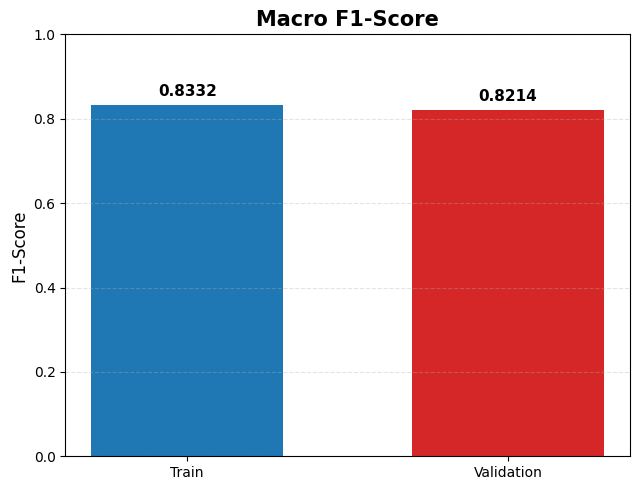

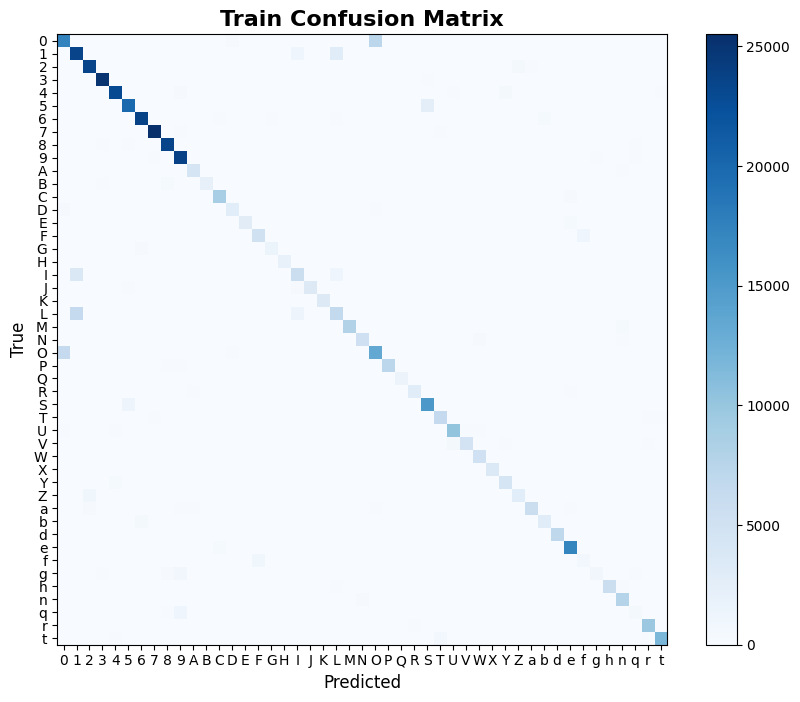

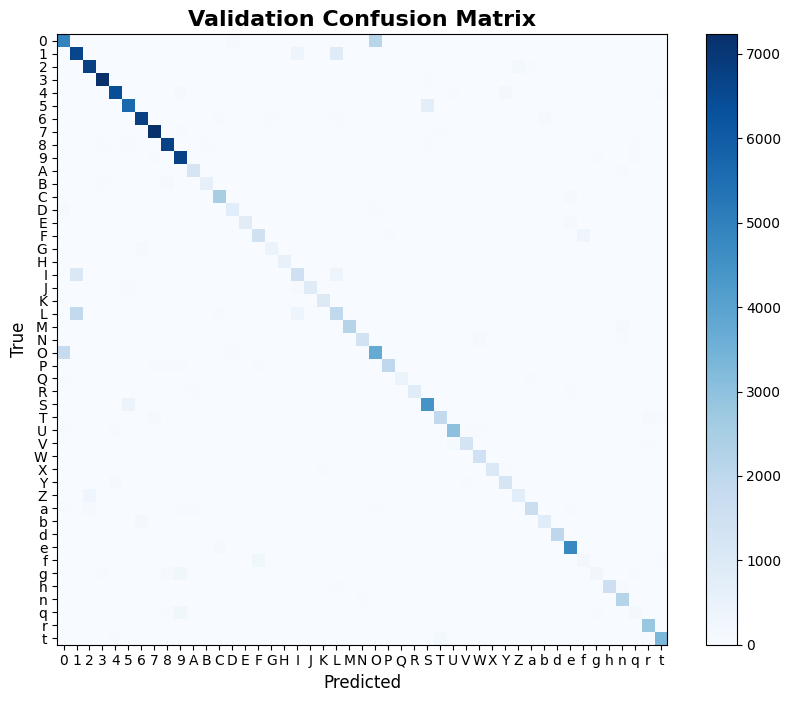

In [37]:
evaluate_model(m1, X_train, y_train, X_val, y_val)

<h2 style="color: #1976D2; font-weight: 500">
    4. Desarrollo de una Red Neuronal con PyTorch
</h2>

Device y Dataset

In [38]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).long()

X_val_tensor = torch.from_numpy(X_val).float()
y_val_tensor = torch.from_numpy(y_val).long()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

del X_train
del y_train
del X_val
del y_val

Using mps device


<h3 style="color: #00B0FF; font-weight: 400">
    Modelo M2
</h3>

In [ ]:
config_m2 = config_m1
m2 = MLP(input_dim, config_m2["layers"], output_dim, dropout=0., activation=nn.ReLU)
optimizer_m2 = torch.optim.Adam(m2.parameters(), weight_decay=config_m2["l2"])
loss_fn_m2 = torch.nn.CrossEntropyLoss()

train_loader_m2 = DataLoader(
    train_dataset,
    batch_size=config_m2["batch_size"],
    shuffle=True
)

val_loader_m2 = DataLoader(
    val_dataset,
    batch_size=config_m2["batch_size"],
    shuffle=False
)

m2_test = deepcopy(m2)

Training

In [40]:
m2 = m2.to(device)

train_loss, val_loss, last_epoch_m2 = train_and_eval(train_loader_m2, val_loader_m2, m2, loss_fn_m2, 
    optimizer_m2, device, epochs=total_epochs, early_stopping=early_stopping, 
    scheduling=config_m2["scheduling"])

 14%|█▍        | 21/150 [04:38<28:30, 13.26s/it]

Early stopping after epoch: 21


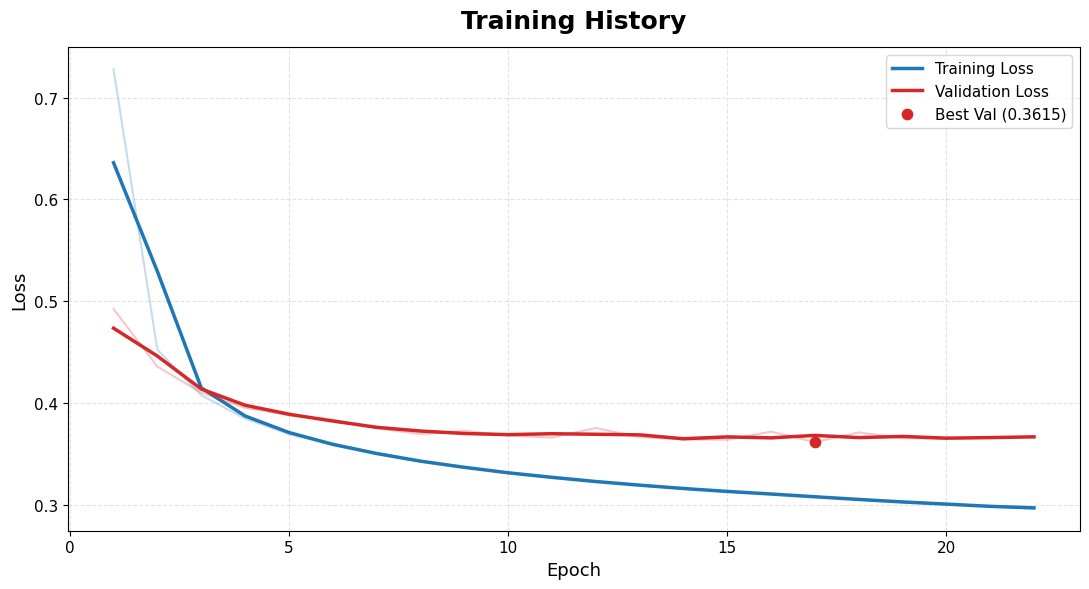

In [41]:
plot_training_history(train_loss, val_loss)

Métricas

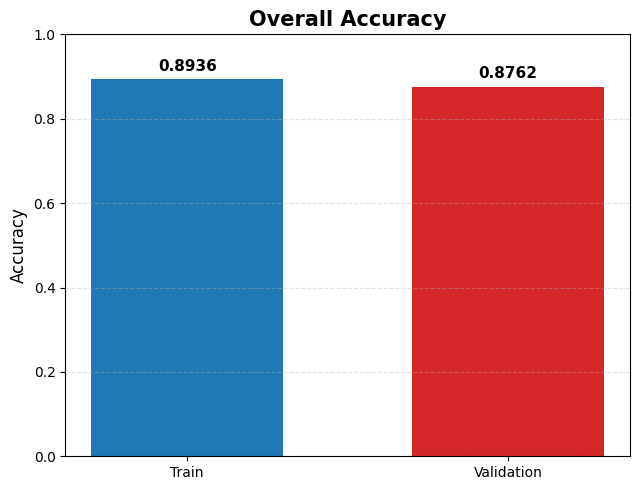

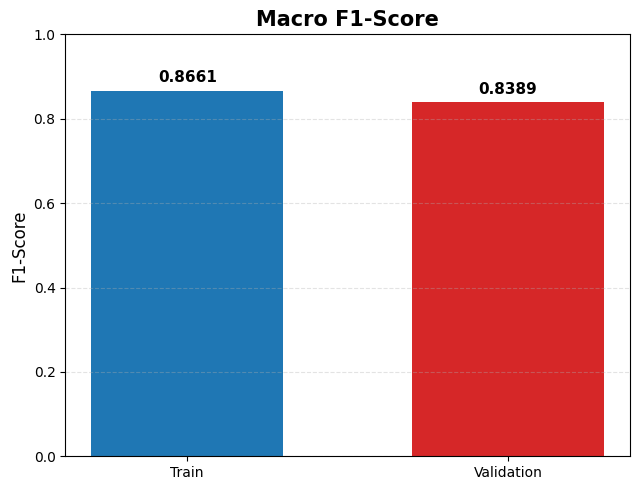

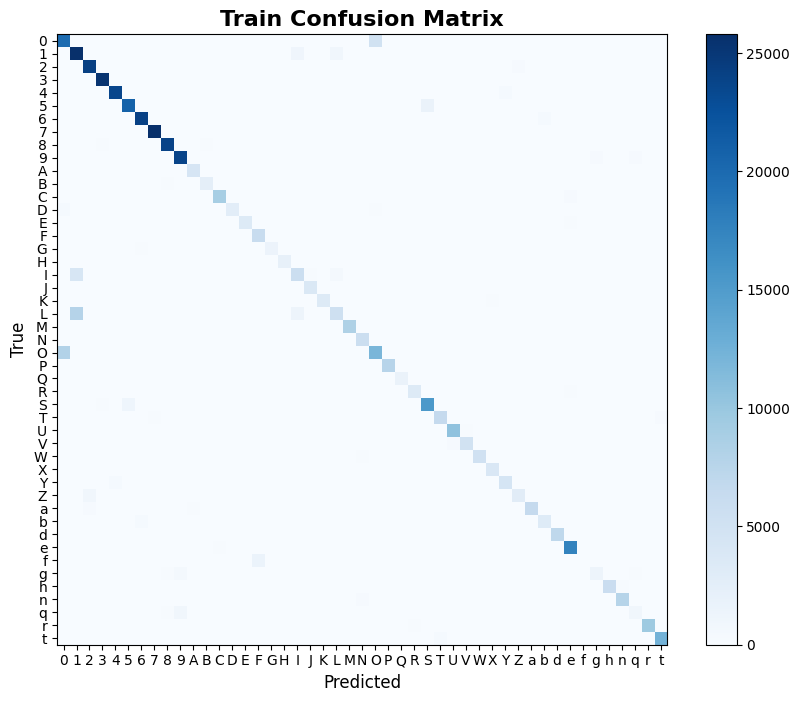

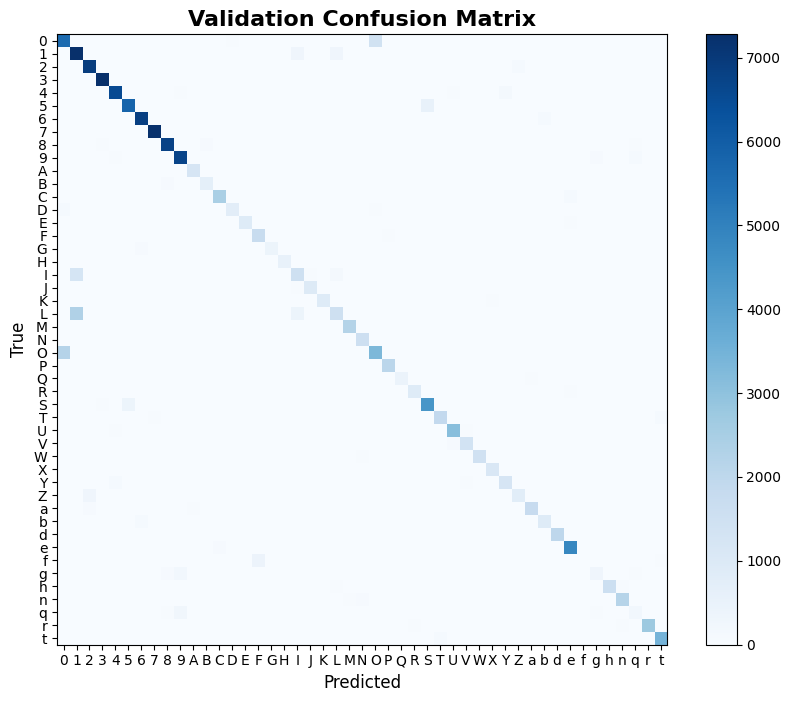

In [42]:
evaluate_model(
    m2, 
    X_train_tensor.detach().cpu().numpy(), 
    y_train_tensor.detach().cpu().numpy(), 
    X_val_tensor.detach().cpu().numpy(), 
    y_val_tensor.detach().cpu().numpy()
)

**Random Grid Search para M3**

In [43]:
X_train_search_tensor = torch.from_numpy(X_train_search).float()
y_train_search_tensor = torch.from_numpy(y_train_search).long()

X_val_search_tensor = torch.from_numpy(X_val_search).float()
y_val_search_tensor = torch.from_numpy(y_val_search).long()

del X_train_search
del y_train_search
del X_val_search
del y_val_search

train_search_dataset = TensorDataset(X_train_search_tensor, y_train_search_tensor)
val_search_dataset = TensorDataset(X_val_search_tensor, y_val_search_tensor)

possible_configs = {
    "layers": [
        [128, 64],
        [256, 128],
        [512, 256, 128],
    ],
    "dropout": [0.0, 0.2, 0.4],
    "l2": [0.0, 1e-5, 1e-3],
    "batch_size": [64, 128, 256],
    "optimizer": [torch.optim.AdamW],
    "activation": [nn.ReLU, nn.LeakyReLU, nn.SiLU],
    "batch_norm": [True, False],
    "scheduling": [
        None, 
        {"type": "linear", "lr_min": 1e-5, "k": 1e-5}, 
        {"type": "exponential", "gamma": 0.99}]
}

epochs_search = 100
K_models = 7

In [44]:
models, model_configs = random_grid_search_torch(input_dim, output_dim, train_search_dataset, val_search_dataset, 
    epochs_search, K_models, possible_configs, early_stopping, device)

  0%|          | 0/7 [00:00<?, ?it/s]


Model: 0
Config: {'layers': [512, 256, 128], 'dropout': 0.0, 'l2': 0.0, 'batch_size': 256, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'activation': <class 'torch.nn.modules.activation.ReLU'>, 'batch_norm': True, 'scheduling': None}



 14%|█▍        | 1/7 [00:27<02:45, 27.57s/it]

Early stopping after epoch: 13

Model: 1
Config: {'layers': [512, 256, 128], 'dropout': 0.0, 'l2': 0.001, 'batch_size': 256, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'activation': <class 'torch.nn.modules.activation.SiLU'>, 'batch_norm': False, 'scheduling': None}



 29%|██▊       | 2/7 [00:55<02:18, 27.69s/it]

...

Early stopping after epoch: 60

Model: 5
Config: {'layers': [128, 64], 'dropout': 0.0, 'l2': 1e-05, 'batch_size': 64, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'activation': <class 'torch.nn.modules.activation.LeakyReLU'>, 'batch_norm': False, 'scheduling': None}



 86%|████████▌ | 6/7 [06:34<01:18, 78.01s/it]

Early stopping after epoch: 14

Model: 6
Config: {'layers': [512, 256, 128], 'dropout': 0.2, 'l2': 0.001, 'batch_size': 64, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'activation': <class 'torch.nn.modules.activation.ReLU'>, 'batch_norm': False, 'scheduling': {'type': 'exponential', 'gamma': 0.99}}



100%|██████████| 7/7 [08:17<00:00, 71.03s/it]

Early stopping after epoch: 18


In [45]:
compare_models(models, list(model_configs.keys()))

 Model  Best Val Loss  Best Train Loss  Best Epoch  Final Train Loss  Final Val Loss  Epochs Trained
     6       0.388232         0.349586          14          0.322680        0.406051              19
     3       0.398470         0.475685          17          0.460590        0.404801              22
     1       0.399058         0.269562           9          0.200553        0.453893              14
     0       0.410106         0.292141           9          0.225062        0.454265              14
     5       0.454322         0.349620          10          0.303450        0.474706              15
     2       0.456906         0.338882          10          0.288599        0.489196              15
     4       0.513399         0.730312          56          0.727217        0.517422              61


<h3 style="color: #00B0FF; font-weight: 400">
    Modelo M3
</h3>

In [ ]:
config_m3 = get_best_config(models, model_configs)

m3 = MLP(input_dim, config_m3["layers"], output_dim, config_m3["dropout"], 
    config_m3["activation"], config_m3["batch_norm"])

train_loader_m3 = DataLoader(
    train_dataset,
    batch_size=config_m3["batch_size"],
    shuffle=True
)

val_loader_m3 = DataLoader(
    val_dataset,
    batch_size=config_m3["batch_size"],
    shuffle=False
)

loss_fn_m3 = nn.CrossEntropyLoss()
optimizer_m3 = config_m3["optimizer"](m3.parameters(), weight_decay=config_m3["l2"])

m3_test = deepcopy(m3)

In [47]:
m3 = m3.to(device)

train_loss, val_loss, last_epoch_m3 = train_and_eval(train_loader_m3, val_loader_m3, m3, loss_fn_m3, 
    optimizer_m3, device, epochs=total_epochs, early_stopping=early_stopping, 
    scheduling=config_m3["scheduling"])

 22%|██▏       | 33/150 [17:47<1:03:05, 32.36s/it]

Early stopping after epoch: 33


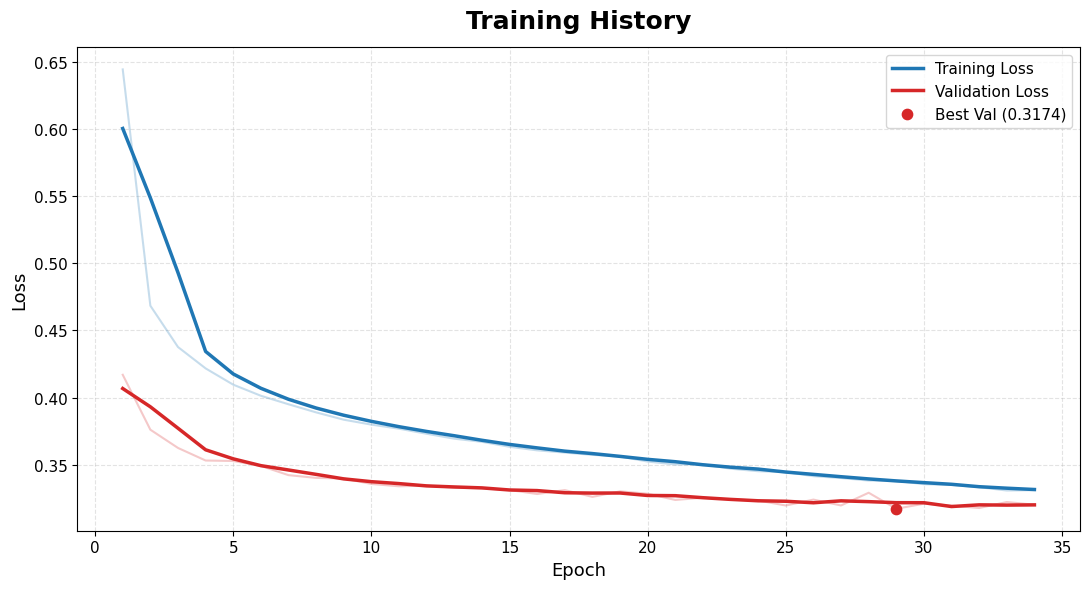

In [48]:
plot_training_history(train_loss, val_loss)

Métricas

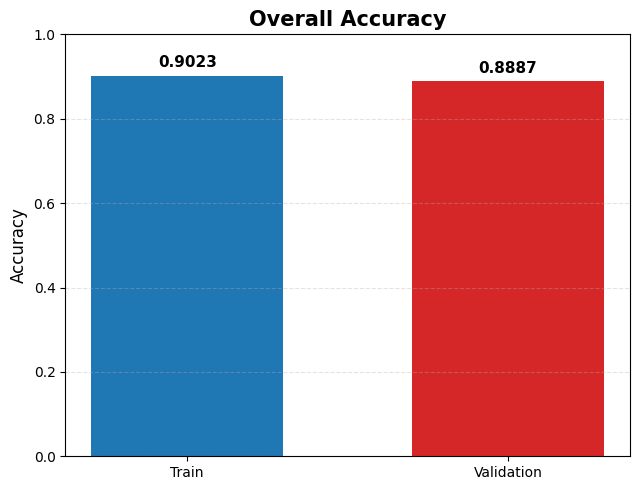

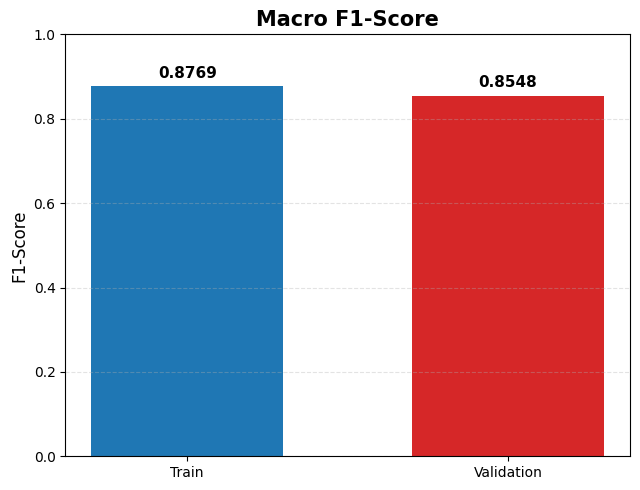

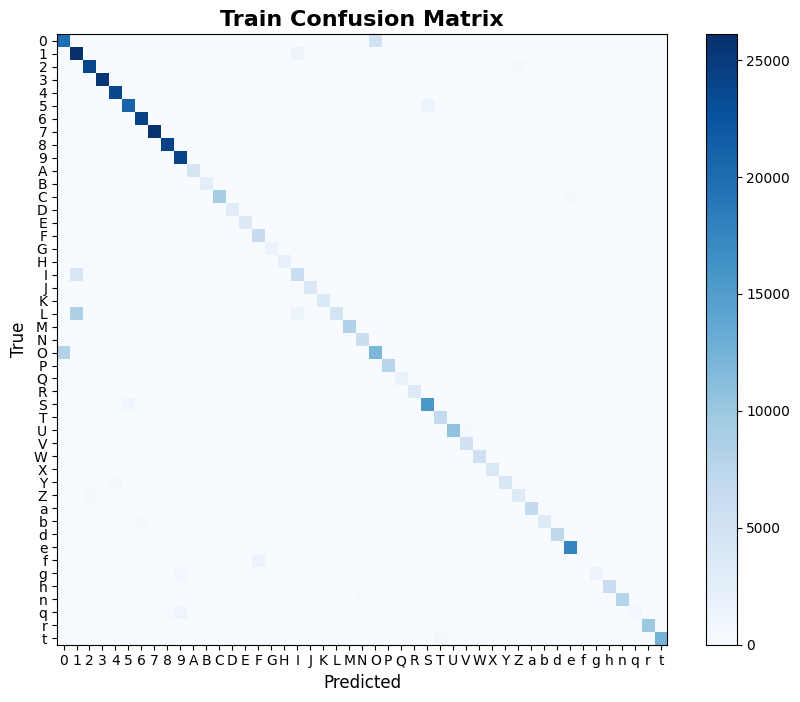

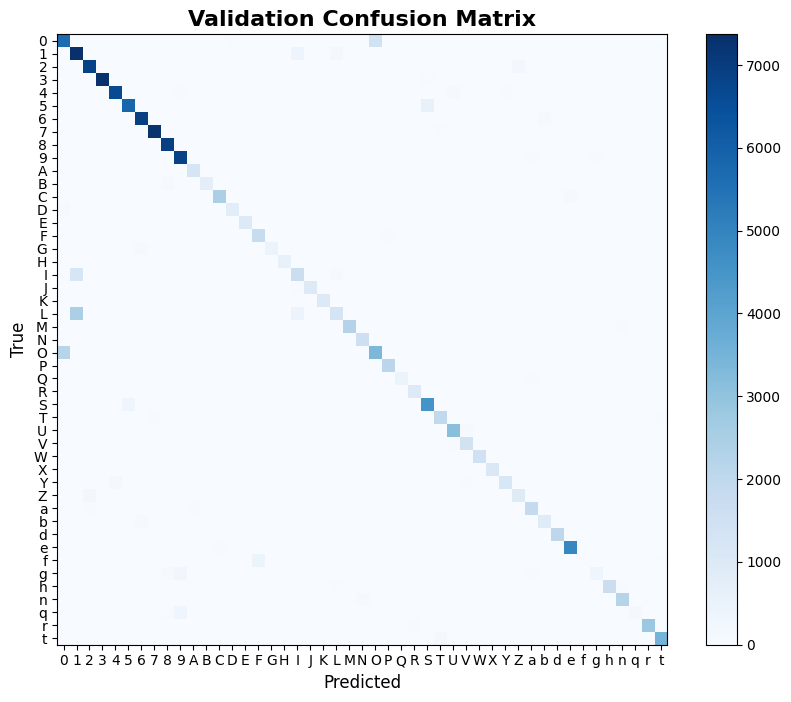

In [49]:
evaluate_model(
    m3, 
    X_train_tensor.detach().cpu().numpy(), 
    y_train_tensor.detach().cpu().numpy(), 
    X_val_tensor.detach().cpu().numpy(), 
    y_val_tensor.detach().cpu().numpy()
)

<h3 style="color: #00B0FF; font-weight: 400">
    Performance de los modelos con respecto a test
</h3>

Primero entreno todos los modelos usando **DEV** con la cantidad de epochs que entrenó para la partición train / val y luego evalúo en todo **TEST**



In [ ]:
X_dev_tensor = torch.from_numpy(X_dev).float()
y_dev_tensor = torch.from_numpy(y_dev).long()

dev_dataset = TensorDataset(X_dev_tensor, y_dev_tensor)

**M0**

In [51]:
m0_test.fit(X_dev, y_dev, last_epoch_m0, batch_size=None)

y_pred_m0 = m0_test.predict(X_test)

Training: 100%|██████████| 150/150 [36:17<00:00, 14.51s/ep]


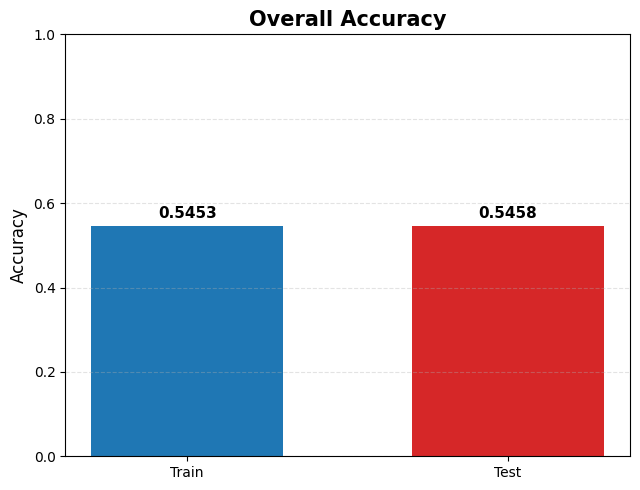

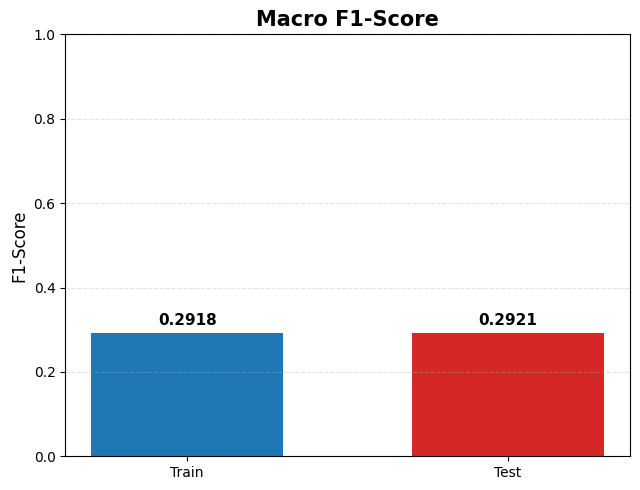

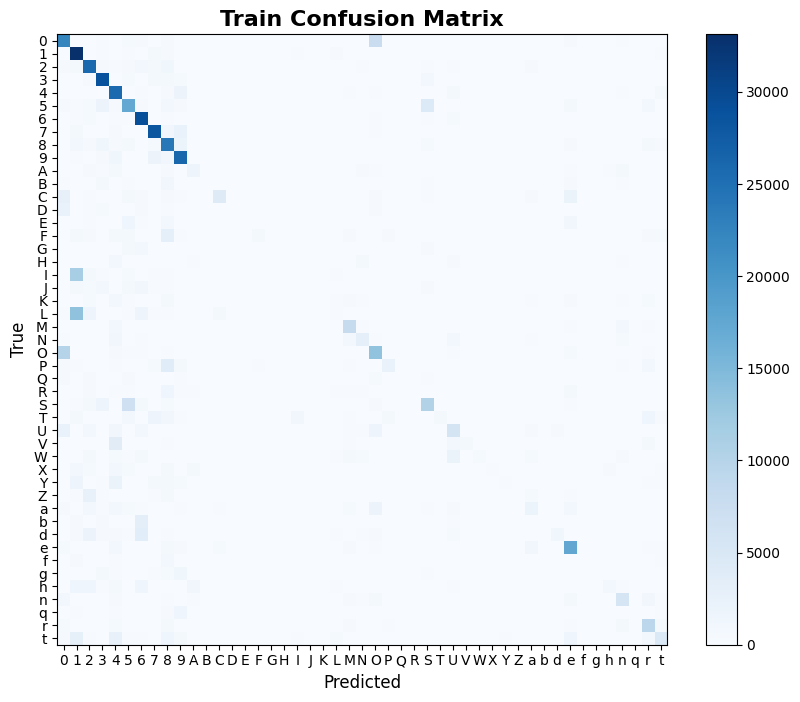

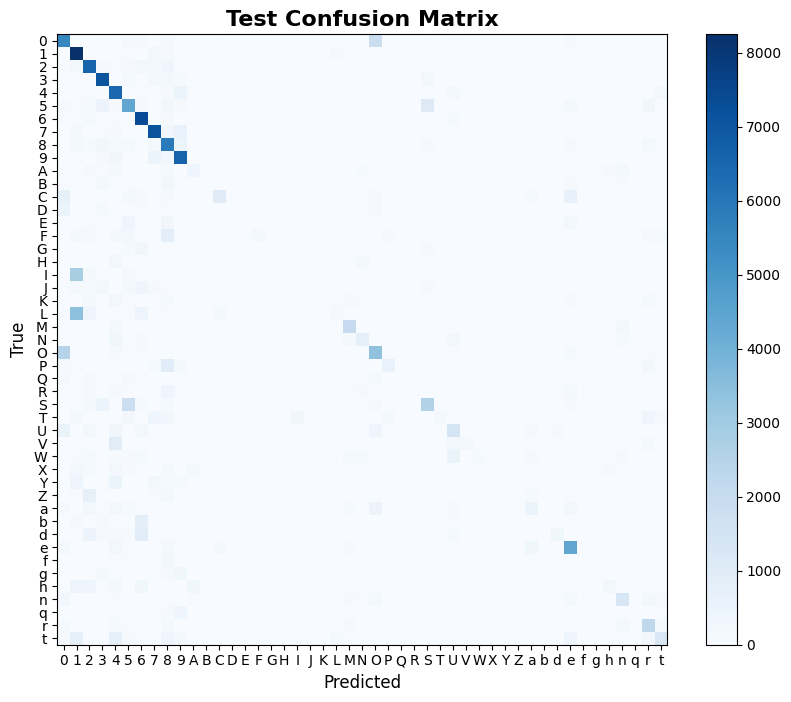

In [ ]:
evaluate_model(m0_test, X_dev, y_dev, X_test, y_test, val_name="Test")

**M1**

In [54]:
m1_test.fit(X_dev, y_dev, last_epoch_m1, config_m1["batch_size"])

y_pred_m1 = m1_test.predict(X_test)

Training: 100%|██████████| 11/11 [15:53<00:00, 86.72s/ep] 


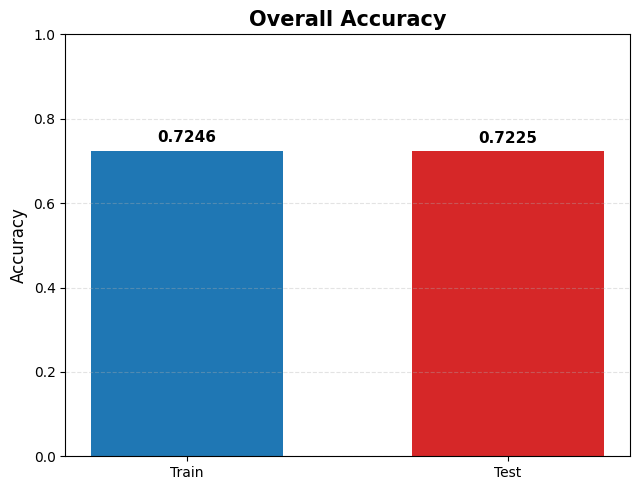

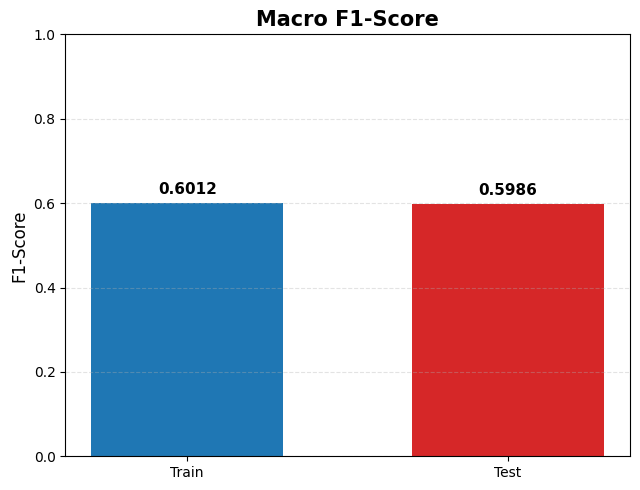

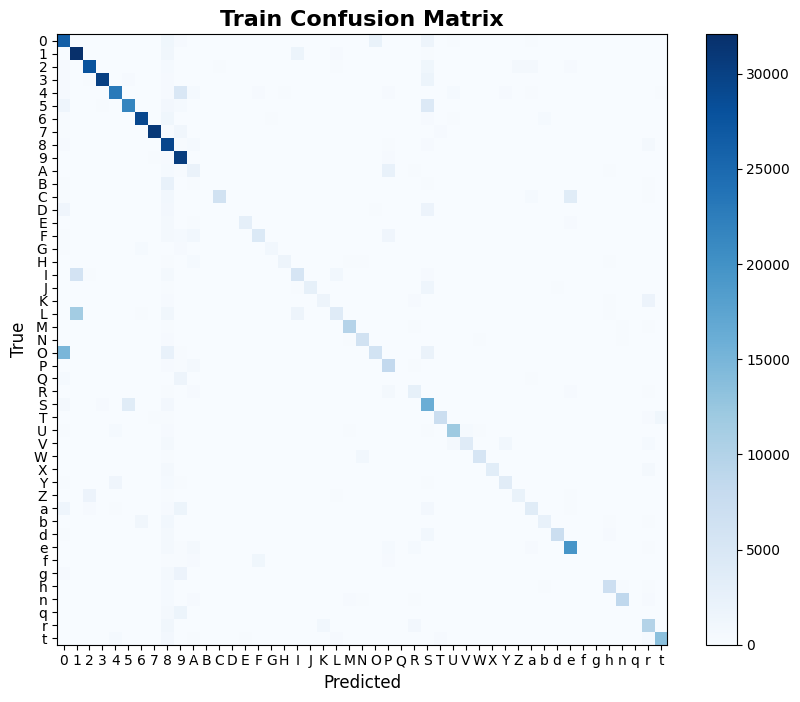

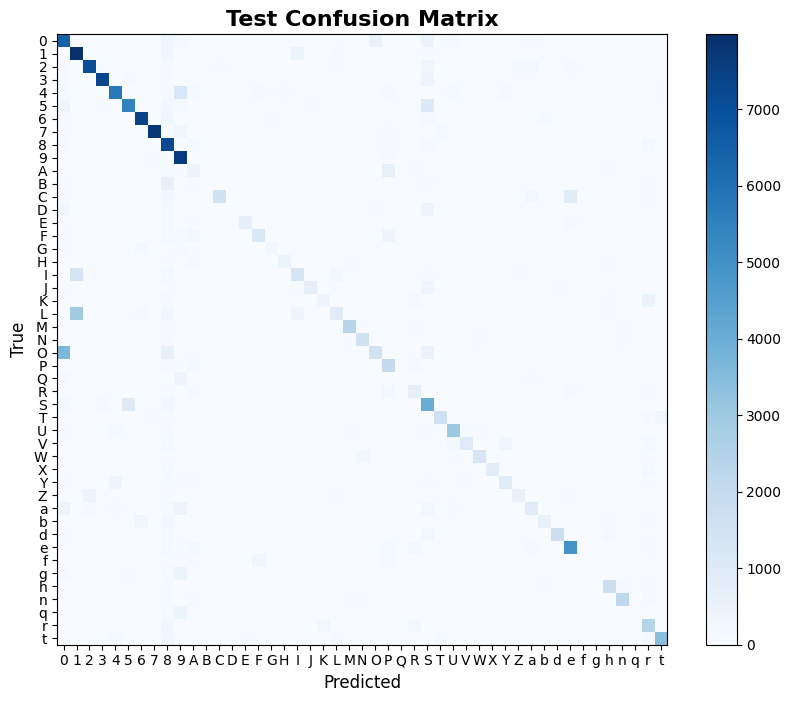

In [55]:
evaluate_model(m1_test, X_dev, y_dev, X_test, y_test, val_name="Test")

**M2**

In [ ]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

dev_loader_m2 = DataLoader(
    dev_dataset,
    batch_size=config_m2["batch_size"],
    shuffle=True
)

m2_test.to(device)

optimizer_m2_test = torch.optim.Adam(m2_test.parameters(), weight_decay=config_m2["l2"])

for t in tqdm(range(last_epoch_m2)):
    train_loop(dev_loader_m2, m2_test, nn.CrossEntropyLoss(), optimizer_m2_test, device)
    
m2_test.eval()

with torch.no_grad():
    logits_m2 = m2_test(X_test_tensor)
    y_pred_m2 = torch.argmax(logits_m2, dim=1)

100%|██████████| 17/17 [03:28<00:00, 12.27s/it]


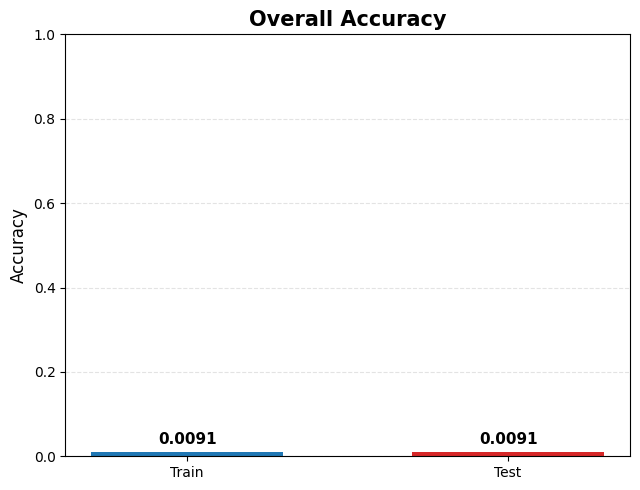

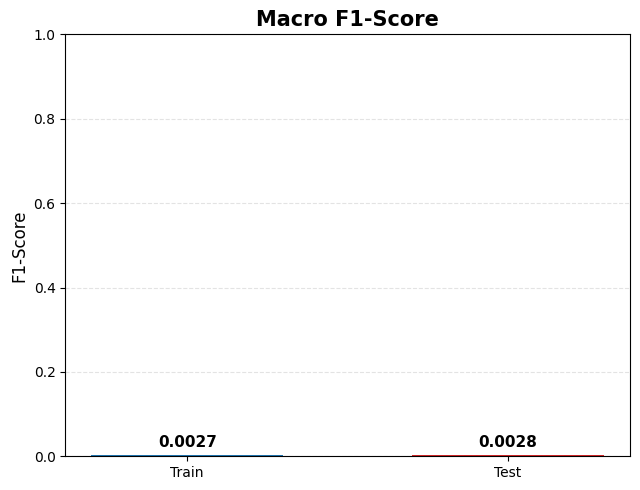

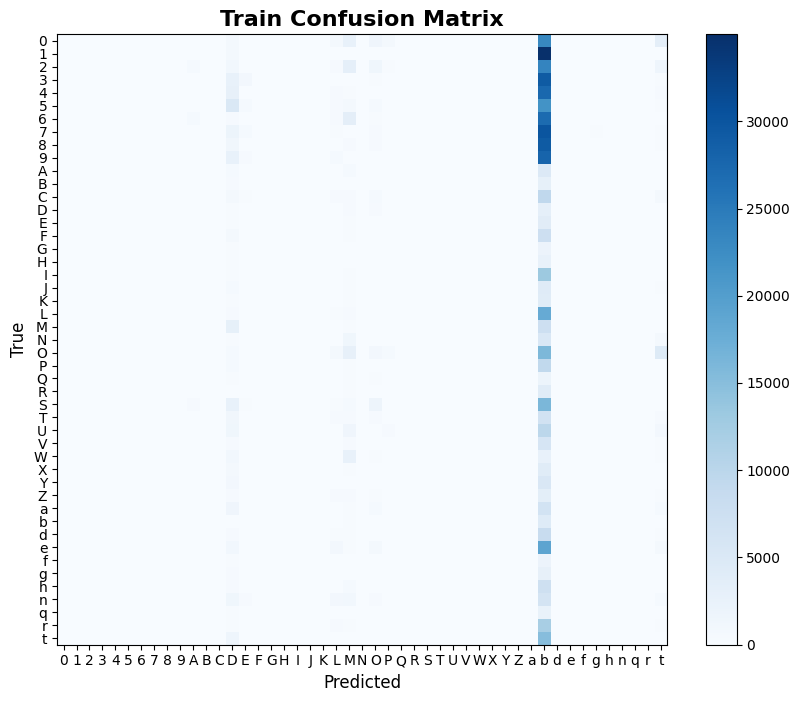

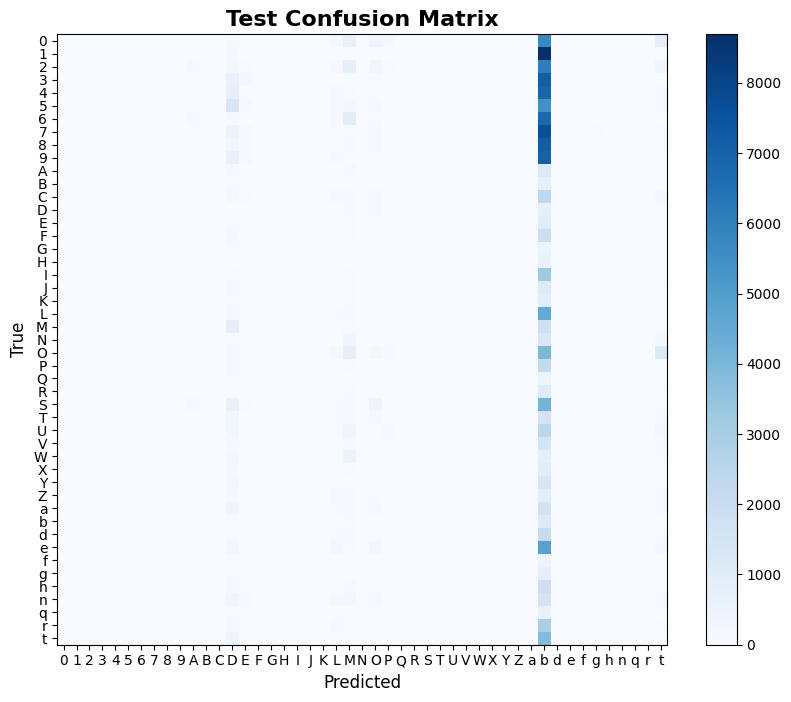

In [57]:
evaluate_model(m2_test, X_dev, y_dev, X_test, y_test, val_name="Test")

**M3**

In [ ]:
dev_loader_m3 = DataLoader(
    dev_dataset,
    batch_size=config_m3["batch_size"],
    shuffle=True
)

m3_test.to(device)

optimizer_m3_test = config_m3["optimizer"](m3_test.parameters(), weight_decay=config_m3["l2"])

for t in tqdm(range(last_epoch_m3)):
    train_loop(dev_loader_m3, m3_test, nn.CrossEntropyLoss(), optimizer_m3_test, device)
    
m3_test.eval()

with torch.no_grad():
    logits_m3 = m3_test(X_test_tensor)
    y_pred_m3 = torch.argmax(logits_m3, dim=1)

100%|██████████| 29/29 [12:06<00:00, 25.04s/it]


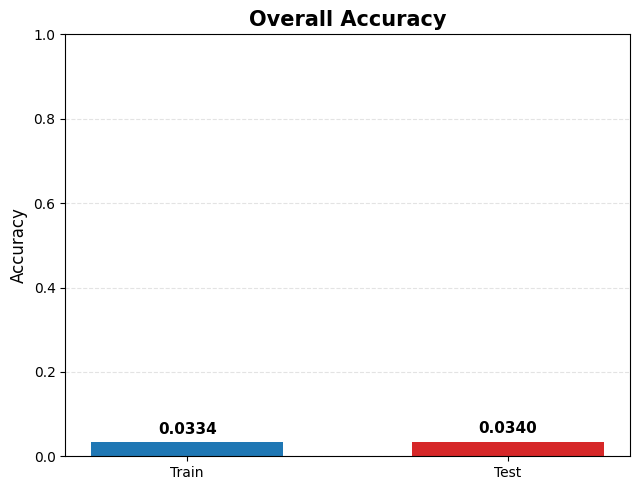

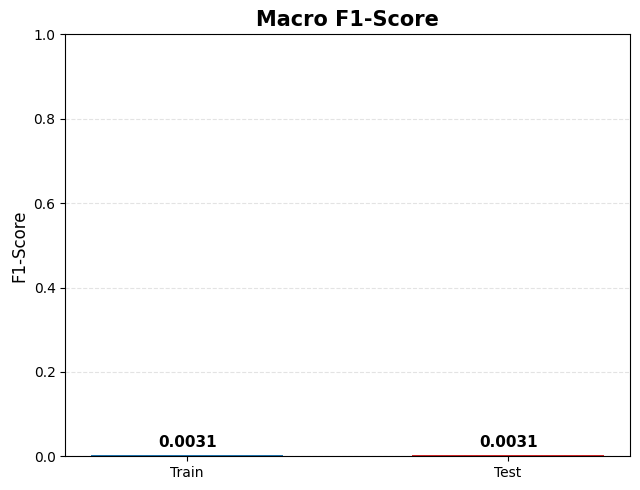

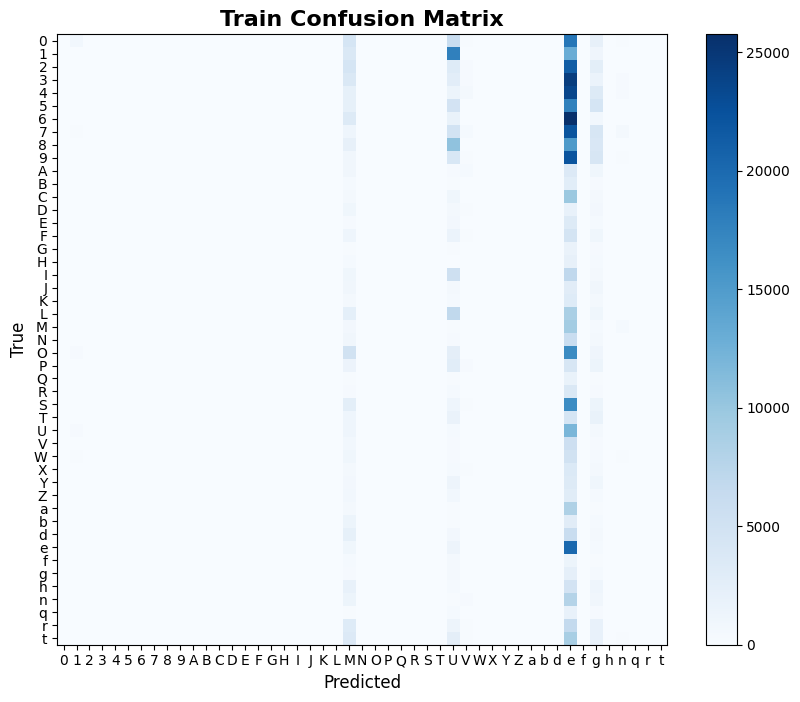

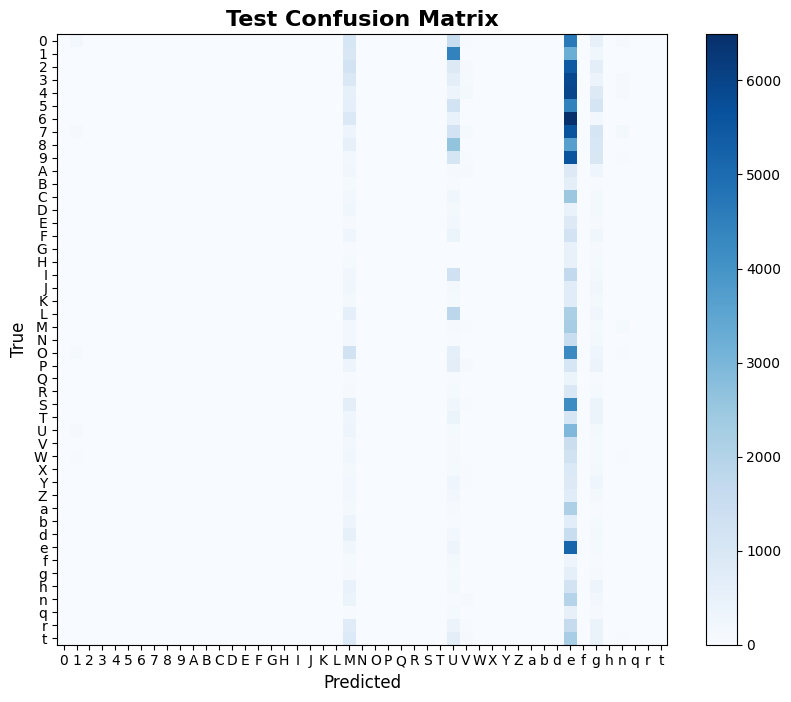

In [59]:
evaluate_model(m3_test, X_dev, y_dev, X_test, y_test, val_name="Test")